# 📘 Day 15: Supervised Learning (Deep Theory + Hands-on)


## 🧠 What is Supervised Learning?

Supervised Learning is a machine learning paradigm where the model learns from **labeled data**.

### Key Idea:
We already know:
- Inputs (X)
- Outputs (y)

Goal:
> Learn a function that maps X → y

### Mathematical Form:
y = f(X)

---

## 🧠 Intuition (Very Important)

Think of it like learning from experience:

- Past data = historical decisions
- Model = pattern learner
- Future prediction = learned behavior

👉 Model does NOT understand logic  
👉 It only learns patterns from data

---

## ⚠️ Important Assumption

> Future data behaves like past data

If this breaks → model fails (Data Drift / Concept Drift)



## 📊 Types of Supervised Learning

### 1. Regression
- Output is continuous
- Example: Salary, Price

### 2. Classification
- Output is discrete
- Example: Fraud / Not Fraud



## ⚙️ Training Process (Core ML Loop)

1. Prediction → y_pred = f(X)
2. Loss Calculation → error between y and y_pred
3. Optimization → update weights
4. Repeat

This loop is powered by:
- Loss Function
- Gradient Descent


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score


## 🧪 Hands-on 1: Regression (Salary Prediction)


### Problem:
Predict salary based on experience

### Learning Objective:
- Understand relationship learning
- Visualize regression line


In [3]:

np.random.seed(42)

experience = np.random.randint(1, 15, 100)
salary = experience * 6000 + np.random.randint(-3000, 3000, 100)

df = pd.DataFrame({'Experience': experience, 'Salary': salary})
df.head()


,Experience,Salary
0,7,42798
1,4,22275
2,13,76016
3,11,63337
4,8,45878


In [4]:

X = df[['Experience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [5]:

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))


MSE: 3967819.070316551


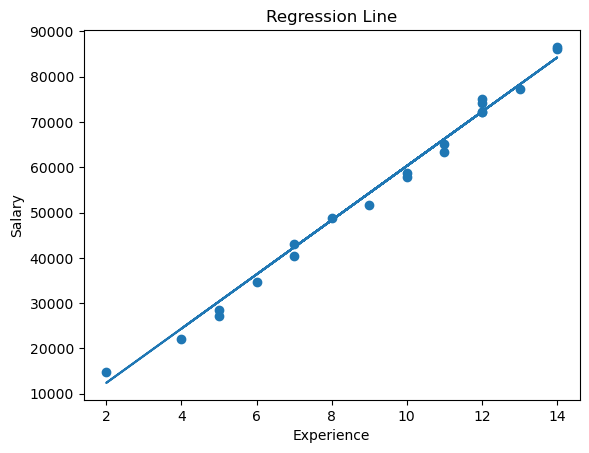

In [6]:

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Regression Line")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()


## 🧪 Hands-on 2: Classification (Loan Approval - BFSI)


### Problem:
Predict loan approval using:
- Income
- Credit Score

### Real-world Relevance:
Used in banking risk systems


In [11]:

income = np.random.randint(20000, 120000, 200)
credit_score = np.random.randint(300, 850, 200)

approval = (income > 60000) & (credit_score > 650)
approval = approval.astype(int)

df = pd.DataFrame({
    'Income': income,
    'CreditScore': credit_score,
    'Approved': approval
})

df.head()


,Income,CreditScore,Approved
0,35048,361,0
1,55111,444,0
2,57904,515,0
3,74912,302,0
4,54008,459,0


In [8]:

X = df[['Income', 'CreditScore']]
y = df['Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.925



## ⚠️ Overfitting vs Underfitting

### Overfitting:
- Model memorizes training data
- Fails on new data

### Underfitting:
- Model too simple
- Cannot learn pattern

👉 Goal: Balance both



## 🚀 Mini Project (Portfolio Ready)

### Build:
Loan Risk Predictor

### Steps:
- Add features: Age, Loan Amount
- Try different models
- Compare accuracy
- Add evaluation metrics

### Bonus:
- Visualize decision boundary
